# On Analyzing Real World Time Series using the Wesad Dataset

[WESAD (Wearable Stress and Affect Detection)](https://archive.ics.uci.edu/dataset/465/wesad+wearable+stress+and+affect+detection)

In [1]:
import os
import sys

import pandas as pd

from tqdm import tqdm
# Get the current working directory of the notebook
notebook_dir = os.getcwd()
# print(notebook_dir)

# Add the parent directory to the system path
sys.path.append(os.path.join(notebook_dir, '../../framework_for_time_series_data/tslearn/'))
# from collections import namedtuple
from data_loader import build_wesad_mts
from time_series import TimeSeriesFactory, TimeSeriesMixin, MultivariateTimeSeries

/Users/detraviousjamaribrinkley/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
pd.set_option('max_colwidth', 800)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

## Load Chest and Wrist Data

- Synchronised raw sensor data and labels

### Data Attributes

- Chest: RespiBAN device
    - Sampled at 700 Hz
    1. **ACC_x:**
    2. **ACC_y:**
    3. **ACC_z:**
    4. **ECG:**
    5. **EMG:**
    6. **EDA:**
    7. **Temp:**
    8. **Resp:**
    9. **Subject:** The participant in the study
    10. **Label:** ID of the respective study protocol condition
        - 0 = not defined / transient
        - 1 = baseline
        - 2 = stress
        - 3 = amusement
        - 4 = meditation
        - 5/6/7 = should be ignored in this dataset
- Wrist: Empatica E4 device


In [3]:
chest_mts, wrist_mts = build_wesad_mts()
chest_mts

['ACC_x', 'ACC_y', 'ACC_z', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp', 'subject', 'label']
['ACC_x', 'ACC_y', 'ACC_z', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp', 'subject', 'label']


MultivariateTimeSeries(('ACC_x',), ('ACC_y',), ('ACC_z',), ('ECG',), ('EMG',), ('EDA',), ('Temp',), ('Resp',), ('subject',), ('label',))

- There exists 700 rows per 1 second. Can agg across 1 second or perform another analysis across all 700 rows for that 1 sec.

In [4]:
unit_of_time = 's'
start_time = 0
sampling_rate = 700  # Hz

chest_mts.update_with_sampling_rate(unit_of_time, start_time, sampling_rate)

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0 days 00:00:00,0.9554,-0.222,-0.558,0.021423,-0.00444,5.250549,30.120758,-1.148987,S2,0
0 days 00:00:00.001428571,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,S2,0
0 days 00:00:00.002857142,0.9082,-0.2196,-0.5392,0.016525,0.005173,5.243301,30.138214,-1.152039,S2,0
0 days 00:00:00.004285713,0.8974,-0.2102,-0.5122,0.016708,0.007187,5.249405,30.129517,-1.158142,S2,0
0 days 00:00:00.005714284,0.8882,-0.2036,-0.4824,0.011673,-0.015152,5.286407,30.13095,-1.161194,S2,0
...,...,...,...,...,...,...,...,...,...,...
1 days 00:07:47.966796745,0.9006,-0.04,-0.1898,0.173676,-0.005539,7.265091,33.862762,0.318909,S17,0
1 days 00:07:47.968225316,0.9022,-0.0398,-0.1872,0.168777,-0.004944,7.266617,33.85974,0.233459,S17,0
1 days 00:07:47.969653887,0.9028,-0.0424,-0.1864,0.16713,-0.016068,7.262802,33.86429,0.318909,S17,0
1 days 00:07:47.971082458,0.9002,-0.0408,-0.1854,0.170334,0.005173,7.269669,33.862762,0.308228,S17,0


In [5]:
chest_df = chest_mts.get_as_df()
chest_df

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0 days 00:00:00,0.9554,-0.222,-0.558,0.021423,-0.00444,5.250549,30.120758,-1.148987,S2,0
0 days 00:00:00.001428571,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,S2,0
0 days 00:00:00.002857142,0.9082,-0.2196,-0.5392,0.016525,0.005173,5.243301,30.138214,-1.152039,S2,0
0 days 00:00:00.004285713,0.8974,-0.2102,-0.5122,0.016708,0.007187,5.249405,30.129517,-1.158142,S2,0
0 days 00:00:00.005714284,0.8882,-0.2036,-0.4824,0.011673,-0.015152,5.286407,30.13095,-1.161194,S2,0
...,...,...,...,...,...,...,...,...,...,...
1 days 00:07:47.966796745,0.9006,-0.04,-0.1898,0.173676,-0.005539,7.265091,33.862762,0.318909,S17,0
1 days 00:07:47.968225316,0.9022,-0.0398,-0.1872,0.168777,-0.004944,7.266617,33.85974,0.233459,S17,0
1 days 00:07:47.969653887,0.9028,-0.0424,-0.1864,0.16713,-0.016068,7.262802,33.86429,0.318909,S17,0
1 days 00:07:47.971082458,0.9002,-0.0408,-0.1854,0.170334,0.005173,7.269669,33.862762,0.308228,S17,0


In [6]:
type(chest_df)

pandas.core.frame.DataFrame

In [7]:
# add to base code so this will always load as such --- data_loader.py (same for wrist_df)
chest_df.columns = [col[0] if isinstance(col, tuple) else col for col in chest_df.columns]

In [8]:
# sampling_rate = 700  # Hz
# unit_of_time = 's'
# time_index = pd.timedelta_range(start=pd.Timedelta(f'0 {unit_of_time}'), periods=len(chest_df), freq=pd.Timedelta(seconds=1/sampling_rate))

# chest_df.set_index(time_index, inplace=True)
# chest_df

- The below will be MTS and pandas DF used interchangeably. The idea is what we want to do as a DF, we want to write for MTS/UTS.

In [9]:
gb_subject_df = chest_df.groupby(by='subject')
gb_subject_df

In [10]:
s2_df = gb_subject_df.get_group('S2')  # Replace 'S2' with any subject ID
s2_1000_df = s2_df[: 1000]
s2_1000_df

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0 days 00:00:00,0.9554,-0.222,-0.558,0.021423,-0.00444,5.250549,30.120758,-1.148987,S2,0
0 days 00:00:00.001428571,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,S2,0
0 days 00:00:00.002857142,0.9082,-0.2196,-0.5392,0.016525,0.005173,5.243301,30.138214,-1.152039,S2,0
0 days 00:00:00.004285713,0.8974,-0.2102,-0.5122,0.016708,0.007187,5.249405,30.129517,-1.158142,S2,0
0 days 00:00:00.005714284,0.8882,-0.2036,-0.4824,0.011673,-0.015152,5.286407,30.13095,-1.161194,S2,0
...,...,...,...,...,...,...,...,...,...,...
0 days 00:00:01.421428145,0.8554,-0.1444,-0.3348,-0.116501,-0.017075,5.351639,30.083038,-0.602722,S2,0
0 days 00:00:01.422856716,0.8506,-0.1434,-0.3382,-0.118698,0.003891,5.356216,30.085907,-0.299072,S2,0
0 days 00:00:01.424285287,0.8506,-0.145,-0.337,-0.128128,-0.003983,5.372238,30.083038,-0.326538,S2,0
0 days 00:00:01.425713858,0.8482,-0.144,-0.3394,-0.139709,-0.010757,5.356598,30.091736,-0.331116,S2,0


In [11]:
ecg_1000_uts = s2_1000_df.__getitem__('ECG')
ecg_1000_uts

0 days 00:00:00              0.021423
0 days 00:00:00.001428571    0.020325
0 days 00:00:00.002857142    0.016525
0 days 00:00:00.004285713    0.016708
0 days 00:00:00.005714284    0.011673
                               ...   
0 days 00:00:01.421428145   -0.116501
0 days 00:00:01.422856716   -0.118698
0 days 00:00:01.424285287   -0.128128
0 days 00:00:01.425713858   -0.139709
0 days 00:00:01.427142429   -0.149094
Freq: 1428571ns, Name: ECG, Length: 1000, dtype: object

In [12]:
ecg_1000_uts.describe()

count     1000.000000
unique     927.000000
top          0.057449
freq         3.000000
Name: ECG, dtype: float64

In [13]:
# Why are these important? What can we tell about spikes?
ecg_1000_uts.max(), ecg_1000_uts.min(), ecg_1000_uts.quantile()

(0.85784912109375, -0.2947998046875, -0.0514068603515625)

<Axes: >

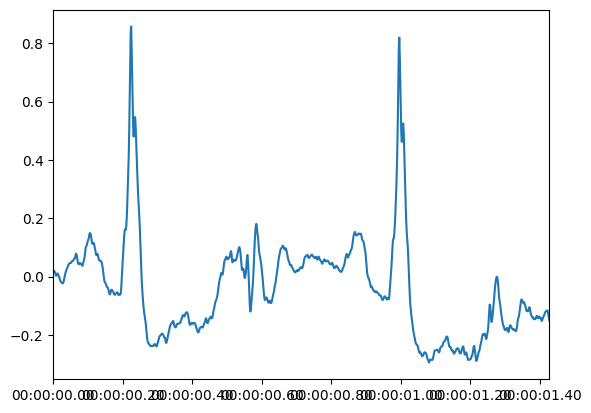

In [ ]:
ecg_1000_uts.plot() # What can we tell about spikes? Abnormal? The normal is less than 0.2

<Axes: >

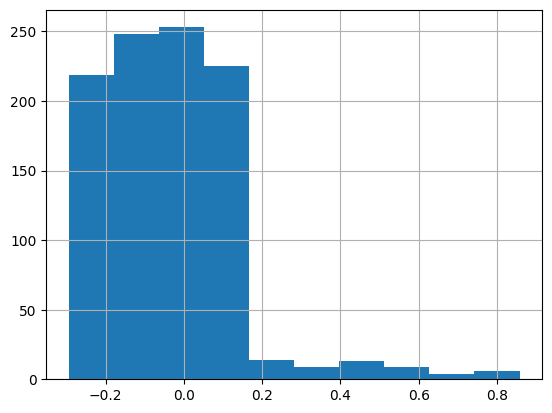

In [15]:
ecg_1000_uts.hist() # Why is this important?

In [16]:
chest_df

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0 days 00:00:00,0.9554,-0.222,-0.558,0.021423,-0.00444,5.250549,30.120758,-1.148987,S2,0
0 days 00:00:00.001428571,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,S2,0
0 days 00:00:00.002857142,0.9082,-0.2196,-0.5392,0.016525,0.005173,5.243301,30.138214,-1.152039,S2,0
0 days 00:00:00.004285713,0.8974,-0.2102,-0.5122,0.016708,0.007187,5.249405,30.129517,-1.158142,S2,0
0 days 00:00:00.005714284,0.8882,-0.2036,-0.4824,0.011673,-0.015152,5.286407,30.13095,-1.161194,S2,0
...,...,...,...,...,...,...,...,...,...,...
1 days 00:07:47.966796745,0.9006,-0.04,-0.1898,0.173676,-0.005539,7.265091,33.862762,0.318909,S17,0
1 days 00:07:47.968225316,0.9022,-0.0398,-0.1872,0.168777,-0.004944,7.266617,33.85974,0.233459,S17,0
1 days 00:07:47.969653887,0.9028,-0.0424,-0.1864,0.16713,-0.016068,7.262802,33.86429,0.318909,S17,0
1 days 00:07:47.971082458,0.9002,-0.0408,-0.1854,0.170334,0.005173,7.269669,33.862762,0.308228,S17,0


In [19]:
# Resample the data to 1 Hz
chest_df_resampled = chest_df.loc[:, ['ACC_x']].resample('1s').mean()
chest_df_resampled

,ACC_x
0 days 00:00:00,0.86331
0 days 00:00:01,0.863901
0 days 00:00:02,0.864235
0 days 00:00:03,0.864287
0 days 00:00:04,0.866042
...,...
1 days 00:07:43,0.905652
1 days 00:07:44,0.905782
1 days 00:07:45,0.907431
1 days 00:07:46,0.901263
